# Trabalho 2 Unidade 2 — A* + MST


**Referências obrigatórias:**
- Notebook-base I: [`week07/Astar.ipnyb`](https://github.com/ivanovitchm/datastructure/blob/main/lessons/week07/Astar.ipynb)  
- Notebook-base II: [`week08/kruskal_natal.ipynb`](https://github.com/ivanovitchm/datastructure/blob/main/lessons/week08/kruskal_natal.ipynb)  

## Objetivo
Dado um conjunto de pontos de interesse (POIs) em uma cidade, estimar quantos quilômetros são suficientes para interligá-los por vias reais.  
Você deverá:
1) Modelar o grafo viário da(s) cidade(s) com OSMnx (ou equivalente);  
2) Calcular rotas mais curtas com A\* entre POIs;  
3) Construir e calcular a Árvore Geradora Mínima (MST) sobre o grafo completo entre POIs (arestas ponderadas pelo custo A\* nas vias) para obter o comprimento total mínimo necessário para conectar todos os POIs;  
4) Comparar o resultado com pelo menos 8 cidades.


<img src="https://drive.google.com/uc?export=view&id=1d84mGH_6c-IZus9QMS8MjYvneVgz68Wf" width="300">



## O que fazer (passo a passo)



### 1) Escolha dos POIs
- Escolha livre dos POIs (ex.: campus, museus, praças, arenas, hubs de transporte, escolas, ponto de onibus, locais turísticos, etc).
- Escolha um POI diferente do Notebook-base II.

### 2) Grafo viário da cidade
- Baixe o grafo viário com OSMnx (`graph_from_place` ou `graph_from_polygon`).  
- Projete o grafo para métrica (UTM) antes de medir distâncias (mesma estratégia usada no Notebook-base II).
- Para cada POI, pegue o nó mais próximo no grafo.

### 3) Rotas mais curtas com A\*
- Para cada par de POIs da cidade, compute o caminho mínimo usando A\* (heurística: distância em linha reta/“great-circle” ou Euclidiana no plano projetado).  
- Registre o custo (distância) de cada par e guarde a rota (lista de nós/arestas) para visualização posterior.  
  - Pode usar `networkx.astar_path`/`astar_path_length` ou implementar A\*.

### 4) MST sobre o grafo completo de POIs
- Com os pesos = distâncias A\* entre cada par de POIs, forme um grafo completo (POIs como vértices).  
- Calcule a MST (ex.: Kruskal) e some os pesos das arestas da MST → “km suficientes para ligar os POIs”.  
- Mapeie de volta cada aresta da MST para a rota na malha viária (união das rotas A\* correspondentes) e compute também o comprimento total real dessa rede resultante.

### 5) Comparação entre ≥ 8 cidades
- Repita os passos 1–4 em pelo menos 8 cidades (pode incluir Natal como uma delas).  
- Compare:  
  - Comprimento da MST (km);   
  - Média e Desvio Padrão por POI (km/POI) ou por par conectado da MST (km/aresta-MST);  

### 6) Visualização e análise
- Plote, para cada cidade, o subgrafo final (união das rotas A\* que compõem a MST entre POIs).  
- Produza tabela comparativa consolidando as métricas.  
- Escreva análise crítica (≈ 10–15 linhas): por que certas cidades exigem mais/menos km? Efeito da escolha de POIs? Limitações do método? O texto deverá estar no arquivo Markdown (README.md)





## Entregáveis


No repositório do grupo, inclua o mesmo formato apresentado no desafio anterior (`week06/challenge.ipynb`).



Critérios de avaliação — **3,0 pontos (Unidade 2)**

1. **Modelagem & dados**
2. **A\* funcional e bem justificado**
3. **MST & reconstrução na malha**
4. **Comparação entre ≥ 8 cidades**
5. **Qualidade do projeto**
6. **Vídeo (até 10 min)**
7. O trabalho poderá ser realizado de forma **individual** ou em **dupla**
8. Prazo: 11 de novembro de 2025 (terça-feira 23h59)

In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import os
import pandas as pd


# Funções

In [2]:
def pois_city(place,tags):
    pois = ox.features.features_from_place(place, tags=tags)

    # Extrair pontos representativos (centroides se for polígono)
    pois_points = []
    for idx, row in pois.iterrows():
        if row.geometry.geom_type == 'Point':
            pois_points.append((row.geometry.y, row.geometry.x))
        else:
            pois_points.append((row.geometry.centroid.y, row.geometry.centroid.x))
    return pois_points, len(pois_points)
    

In [3]:
def to_undirected_multigraph(G):
    """
    Converte um MultiDiGraph direcionado em um MultiGraph não-direcionado,
    preservando atributos dos nós e arestas.
    """
    H = nx.MultiGraph()
    # Copiar nós e seus atributos
    for n, data in G.nodes(data=True):
        H.add_node(n, **data)

    # Copiar arestas e seus atributos, sem direcionamento
    for u, v, data in G.edges(data=True):
            # Em um MultiGraph, se já existir uma aresta u-v, esta será adicionada como mais uma aresta paralela
        H.add_edge(u, v, **data)

    # Copiar atributos do grafo
    H.graph.update(G.graph)
    return H

In [4]:
def road_graph(place):
    G = ox.graph_from_place(place, network_type='drive')

    # Converte para não-direcionado mantendo o tipo MultiGraph
    G_undirected = to_undirected_multigraph(G)

    return G

In [ ]:
def plot_graph_with_pois(G_undirected, POIs_nodes, place, output_dir="../maps"):
    # Garante que a pasta de saída exista
    os.makedirs(output_dir, exist_ok=True)

    # Nome do arquivo (usa o nome da cidade, sem espaços)
    filename = f"{place.replace(',', '').replace(' ', '_')}.png"
    filepath = os.path.join(output_dir, filename)

    # Plotar o grafo base
    fig, ax = ox.plot_graph(
        G_undirected,
        node_size=0,
        edge_color="gray",
        edge_linewidth=0.5,
        show=False,
        close=False
    )
    
    # Plotar os POIs (por exemplo, pontos de recarga) em azul
    poi_x = [G_undirected.nodes[n]['x'] for n in POIs_nodes]
    poi_y = [G_undirected.nodes[n]['y'] for n in POIs_nodes]
    ax.scatter(poi_x, poi_y, c='blue', s=80, zorder=5, edgecolor='black')

    # Título e salvamento
    plt.title(f"POIs em {place}", fontsize=14)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)  # Fecha a figura para liberar memória

    print(f"✅ Mapa salvo em: {filepath}")


In [6]:
def search_nodes(POIs, G_undirected):
    # ============================================
    # 3. Encontrar nós mais próximos dos POIs
    # ============================================
    latitudes = [hp[0] for hp in POIs]
    longitudes = [hp[1] for hp in POIs]
    pois_nodes = ox.distance.nearest_nodes(G_undirected, X=longitudes, Y=latitudes)
    #pois_nodes = list(set(pois_points))
    
    if len(pois_nodes) < 2:
        raise ValueError("POIs insuficientes para criar um MST (menos de 2 pontos).")

    return pois_nodes
        

In [7]:
def build_complete_graph_with_astar(G_undirected,POIs_nodes):

    
    G_interest = nx.Graph()
    
    for i in range(len(pois_nodes)):
        for j in range(i + 1, len(pois_nodes)):
            try:
                # Rota ótima via A*
                route = nx.astar_path(
                    G_undirected,
                    pois_nodes[i],
                    pois_nodes[j],
                    heuristic=lambda u, v: ox.distance.euclidean(
                        G_undirected.nodes[u]['y'], G_undirected.nodes[u]['x'],
                        G_undirected.nodes[v]['y'], G_undirected.nodes[v]['x']
                    ),
                    weight='length'
                )
    
                # Comprimento total da rota
                route_length = sum(
                    G_undirected[route[k]][route[k + 1]][0]['length']
                    for k in range(len(route) - 1)
                )
    
                # Armazena a rota e o comprimento
                G_interest.add_edge(
                    pois_nodes[i],
                    pois_nodes[j],
                    weight=route_length,
                    path=route
                )
    
            except nx.NetworkXNoPath:
                continue
    
    print(f"Grafo de interesse criado com {G_interest.number_of_edges()} arestas.")

    return route,route_length,G_interest

In [ ]:
def plot_paths_astar(G_undirected, G_interest, POIs_nodes, place="cidade", output_dir="../maps"):
    # Garante que a pasta exista
    os.makedirs(output_dir, exist_ok=True)

    # Gera o nome do arquivo (sem espaços nem vírgulas)
    filename = f"{place.replace(',', '').replace(' ', '_')}_astar_paths.png"
    filepath = os.path.join(output_dir, filename)

    # Cria o mapa base
    fig, ax = ox.plot_graph(
        G_undirected,
        show=False,
        close=False,
        node_size=0,
        edge_color="lightgray"
    )

    # Coordenadas dos POIs
    poi_x = [G_undirected.nodes[n]['x'] for n in POIs_nodes]
    poi_y = [G_undirected.nodes[n]['y'] for n in POIs_nodes]
    ax.scatter(poi_x, poi_y, c="blue", s=40, label="POIs (Pontos de Interesse)")

    # Desenha as rotas A* conectando os POIs
    for u, v, data in G_interest.edges(data=True):
        route = data.get("path")
        if route:
            ox.plot_graph_route(
                G_undirected,
                route,
                route_linewidth=2,
                route_alpha=0.6,
                route_color="red",
                orig_dest_size=0,
                ax=ax,
                show=False,
                close=False
            )

    # Título e legenda
    ax.legend()
    plt.title(f"Rotas A* entre Pontos de Interesse (POIs) - {place}", fontsize=12)
    plt.tight_layout()

    # Salva o gráfico
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"✅ Mapa de rotas A* salvo em: {filepath}")


In [9]:
def cal_mst(G_interest):
    # ============================================
    # 5. Calcular o MST
    # ============================================
    mst_edges = list(nx.minimum_spanning_edges(G_interest, data=True))
    total_mst_length = sum([d['weight'] for (u, v, d) in mst_edges])
    print(f"Comprimento total do MST entre os POIs selecionados:{total_mst_length:.2f}, metros ou {(total_mst_length/1000):.2f} Kilomentros")

    return mst_edges, total_mst_length

In [ ]:
def show_mst(mst_edges, G_undirected, POIs_nodes, place, output_dir="../maps"):
    # Garante que a pasta de saída exista
    os.makedirs(output_dir, exist_ok=True)

    # Nome do arquivo (sem espaços nem vírgulas)
    filename = f"{place.replace(',', '').replace(' ', '_')}_mst.png"
    filepath = os.path.join(output_dir, filename)

    mst_routes = []
    for (u, v, d) in mst_edges:
        route = nx.shortest_path(G_undirected, u, v, weight='length')
        mst_routes.append(route)
    
    # Plotar o grafo base
    fig, ax = ox.plot_graph(
        G_undirected, 
        node_size=0, 
        edge_color="gray", 
        edge_linewidth=0.5, 
        show=False, 
        close=False
    )
    
    # Destacar as rotas do MST em vermelho
    for route in mst_routes:
        x = [G_undirected.nodes[n]['x'] for n in route]
        y = [G_undirected.nodes[n]['y'] for n in route]
        ax.plot(x, y, color='red', linewidth=2, zorder=4)
    
    # Plotar também os POIs (hospitais, atrações etc.) em azul
    poi_x = [G_undirected.nodes[n]['x'] for n in POIs_nodes]
    poi_y = [G_undirected.nodes[n]['y'] for n in POIs_nodes]
    ax.scatter(poi_x, poi_y, c='blue', s=80, zorder=5, edgecolor='black', label='POIs')
    
    plt.title(f"MST entre POIs (Atrações Turísticas) em {place}", fontsize=13)
    plt.legend()
    plt.tight_layout()

    # Salvar figura em PNG
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"✅ Mapa MST salvo em: {filepath}")


In [ ]:
# ============================================
# 5. Calcular o MST
# ============================================
mst_edges = cal_mst(G_interest)

In [ ]:
show_mst(mst_edges,G_undirected,pois_nodes,route,place)

# 5) Comparação entre >= 8 cidades  (Cidades do nordeste)

In [15]:
cities = [
    "São Luís, Maranhão, Brasil",
    "Teresina, Piauí, Brasil",
    "Fortaleza, Ceará, Brasil",
    "Natal, Rio Grande do Norte, Brasil",
    "João Pessoa, Paraíba, Brasil",
    "Recife, Pernambuco, Brasil",
    "Maceió, Alagoas, Brasil",
    "Aracaju, Sergipe, Brasil",
    "Salvador, Bahia, Brasil"
]

tags = {
    "tourism": ["attraction", "viewpoint"]
}

distances = []

len_pios = []

for place in cities:
    #1. Obter POIs de interesse (hospitais como exemplo)
    pois_points, length = pois_city(place,tags)
    len_pios.append(length)

    #2. Obter o grafo da cidade
    G_undirected = road_graph(place)

    #3. Encontrar nós mais próximos dos POIs
    pois_nodes = search_nodes(pois_points, G_undirected)
    plot_graph_with_pois(G_undirected, pois_nodes, place)

    # 4. Construir um grafo completo com menor rota entre POIs
    route,route_length,G_interest = build_complete_graph_with_astar(G_undirected,pois_nodes)
    plot_paths_astar(G_undirected, G_interest, pois_nodes, place)

    # 5. Calcular o MST
    mst_edges, lenght_mst = cal_mst(G_interest)
    distances.append(lenght_mst)
    show_mst(mst_edges, G_undirected, pois_nodes, place)

    

✅ Mapa salvo em: maps/São_Luís_Maranhão_Brasil.png
Grafo de interesse criado com 137 arestas.
✅ Mapa de rotas A* salvo em: maps/São_Luís_Maranhão_Brasil_astar_paths.png
Comprimento total do MST entre os POIs selecionados:44557.32, metros ou 44.56 Kilomentros
✅ Mapa MST salvo em: maps/São_Luís_Maranhão_Brasil_mst.png
✅ Mapa salvo em: maps/Teresina_Piauí_Brasil.png
Grafo de interesse criado com 3 arestas.
✅ Mapa de rotas A* salvo em: maps/Teresina_Piauí_Brasil_astar_paths.png
Comprimento total do MST entre os POIs selecionados:2899.16, metros ou 2.90 Kilomentros
✅ Mapa MST salvo em: maps/Teresina_Piauí_Brasil_mst.png
✅ Mapa salvo em: maps/Fortaleza_Ceará_Brasil.png
Grafo de interesse criado com 92 arestas.
✅ Mapa de rotas A* salvo em: maps/Fortaleza_Ceará_Brasil_astar_paths.png
Comprimento total do MST entre os POIs selecionados:31729.84, metros ou 31.73 Kilomentros
✅ Mapa MST salvo em: maps/Fortaleza_Ceará_Brasil_mst.png
✅ Mapa salvo em: maps/Natal_Rio_Grande_do_Norte_Brasil.png
Grafo d

In [19]:

data = {
    "Cidade": cities,
    "Distância_MST_(m)": distances,
    "len_POIs": len_pios
}

df = pd.DataFrame(data)
df

,Cidade,Distância_MST_(m),len_POIs
0,"São Luís, Maranhão, Brasil",44557.324475,18
1,"Teresina, Piauí, Brasil",2899.157113,3
2,"Fortaleza, Ceará, Brasil",31729.842070,15
3,"Natal, Rio Grande do Norte, Brasil",34621.054327,12
4,"João Pessoa, Paraíba, Brasil",36446.448106,37
5,"Recife, Pernambuco, Brasil",42174.483803,68
6,"Maceió, Alagoas, Brasil",34049.508595,15
7,"Aracaju, Sergipe, Brasil",18360.544961,9
8,"Salvador, Bahia, Brasil",84083.124726,39


In [ ]:
df.to_csv("../tabelas/Dados.csv",index=False)

# 6) Visualização e análise

In [ ]:
df_resul = pd.read_csv("../tabelas/Dados.csv")

In [5]:
df_resul['km/poi'] = (df_resul['Distância_MST_(m)']/1000)/df_resul['len_POIs']

In [8]:
df_resul['Distancia_MST(km)'] = df_resul['Distância_MST_(m)']/1000

In [9]:
df_resul

,Cidade,Distância_MST_(m),len_POIs,km/poi,Distancia_MST(km)
0,"São Luís, Maranhão, Brasil",44557.324475,18,2.475407,44.557324
1,"Teresina, Piauí, Brasil",2899.157113,3,0.966386,2.899157
2,"Fortaleza, Ceará, Brasil",31729.842070,15,2.115323,31.729842
3,"Natal, Rio Grande do Norte, Brasil",34621.054327,12,2.885088,34.621054
4,"João Pessoa, Paraíba, Brasil",36446.448106,37,0.985039,36.446448
5,"Recife, Pernambuco, Brasil",42174.483803,68,0.620213,42.174484
6,"Maceió, Alagoas, Brasil",34049.508595,15,2.269967,34.049509
7,"Aracaju, Sergipe, Brasil",18360.544961,9,2.040061,18.360545
8,"Salvador, Bahia, Brasil",84083.124726,39,2.155978,84.083125


In [10]:
mean_km_poi = df_resul["km/poi"].mean()
std_km_poi = df_resul["km/poi"].std()
total_pois = df_resul["len_POIs"].sum()
mean_pois = df_resul["len_POIs"].mean()

# Cria tabela comparativa consolidada
summary = pd.DataFrame({
    "Métrica": [
        "Média (km/POI)",
        "Desvio padrão (km/POI)",
        "Número total de POIs",
        "Média de POIs por cidade",
    ],
    "Valor": [
        mean_km_poi,
        std_km_poi,
        total_pois,
        mean_pois,
    ],
    "Unidade": [
        "km/POI",
        "km/POI",
        "POIs",
        "POIs/cidade",
    ]
})

print("\n=== Tabela Consolidada ===")
print(summary.round(3))

# Opcional: mostrar dados originais com km/aresta
print("\n=== Dados Detalhados ===")
print(df_resul[["Cidade", "Distancia_MST(km)", "len_POIs", "km/poi"]].round(3))



=== Tabela Consolidada ===
                    Métrica    Valor      Unidade
0            Média (km/POI)    1.835       km/POI
1    Desvio padrão (km/POI)    0.781       km/POI
2      Número total de POIs  216.000         POIs
3  Média de POIs por cidade   24.000  POIs/cidade

=== Dados Detalhados ===
                               Cidade  Distancia_MST(km)  len_POIs  km/poi
0          São Luís, Maranhão, Brasil             44.557        18   2.475
1             Teresina, Piauí, Brasil              2.899         3   0.966
2            Fortaleza, Ceará, Brasil             31.730        15   2.115
3  Natal, Rio Grande do Norte, Brasil             34.621        12   2.885
4        João Pessoa, Paraíba, Brasil             36.446        37   0.985
5          Recife, Pernambuco, Brasil             42.174        68   0.620
6             Maceió, Alagoas, Brasil             34.050        15   2.270
7            Aracaju, Sergipe, Brasil             18.361         9   2.040
8             Salvado

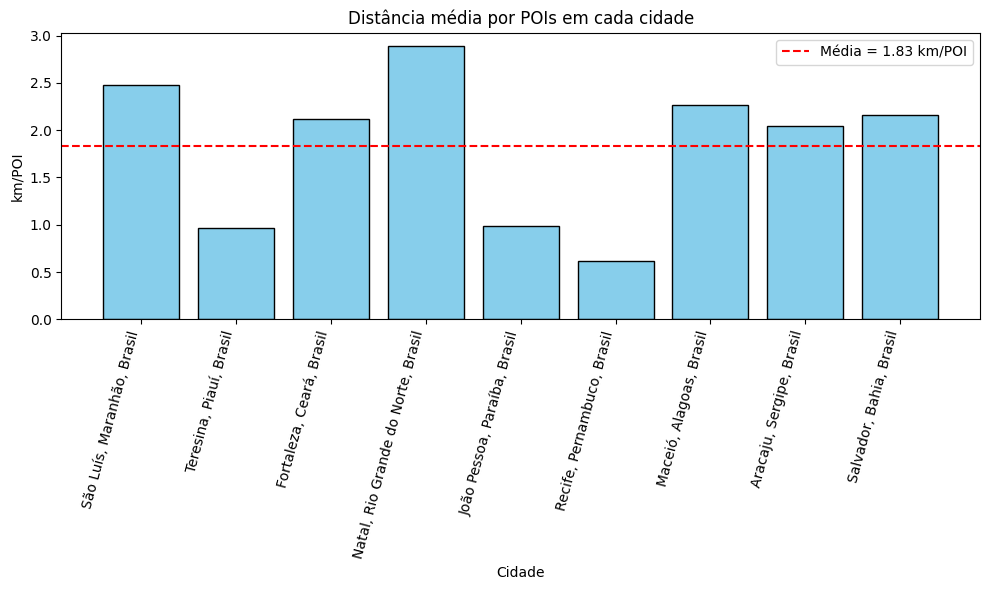

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(df_resul["Cidade"], df_resul["km/poi"], color='skyblue', edgecolor='black')
plt.xticks(rotation=75, ha="right")
plt.xlabel("Cidade")
plt.ylabel("km/POI")
plt.title("Distância média por POIs em cada cidade")

# Linha horizontal mostrando a média
media = df_resul["km/poi"].mean()
plt.axhline(media, color='red', linestyle='--', label=f"Média = {media:.2f} km/POI")
plt.legend()

plt.tight_layout()
plt.show()